In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu130
0.25.0+cu130


# Create Dataset

In [2]:
train_data = datasets.FashionMNIST(
    root = "data",
    train= True,
    download = True,
    transform= torchvision.transforms.ToTensor(),
    target_transform= None
)

test_data = datasets.FashionMNIST(
    root = "data",
    train= False,
    download = True,
    transform= torchvision.transforms.ToTensor(),
    target_transform= None
)

In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
class_name, label = train_data.classes, train_data.targets

# Visualize Data

In [5]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

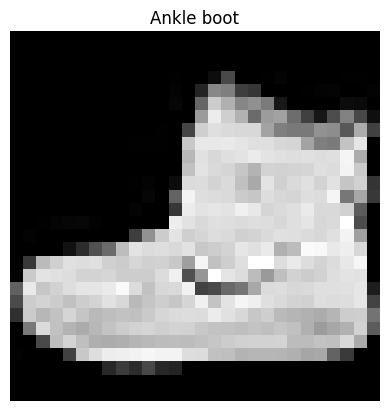

In [6]:
image, label = train_data[0]

plt.title(class_name[label])
plt.imshow(image.permute(1, 2, 0), cmap = "gray")
plt.axis(False)


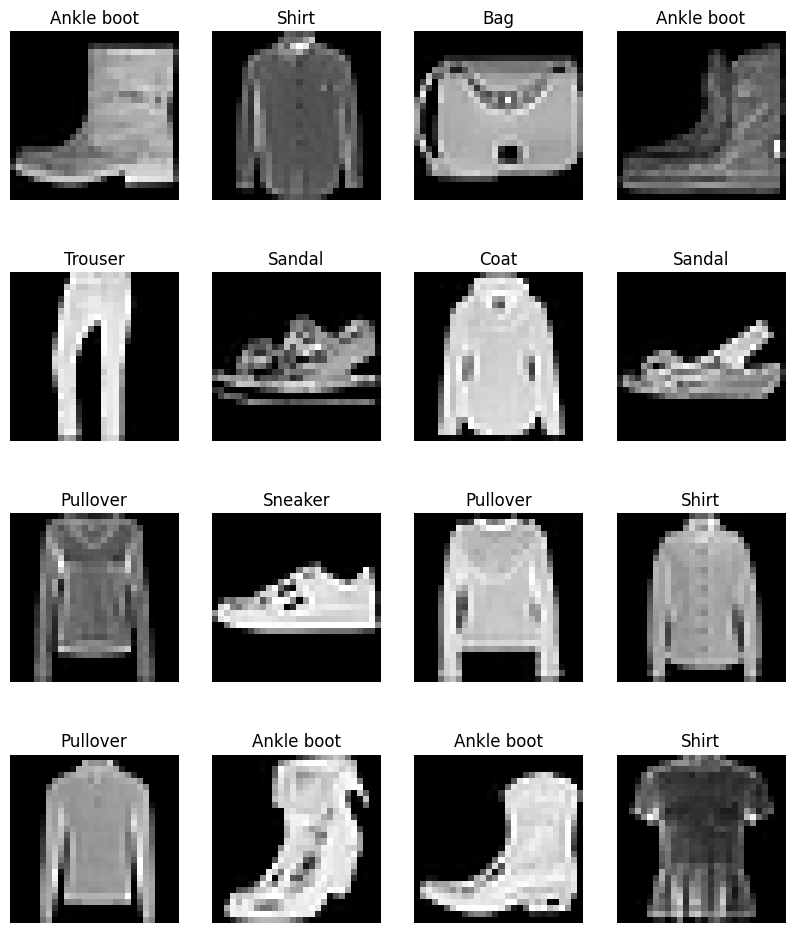

In [7]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(10, 12))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size= [1]).item() # Generates a random tensor with shape (1, )
    img, label = train_data[random_idx] # A random image
    fig.add_subplot(rows, cols, i) # Adds the random image in the subplot in position i
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

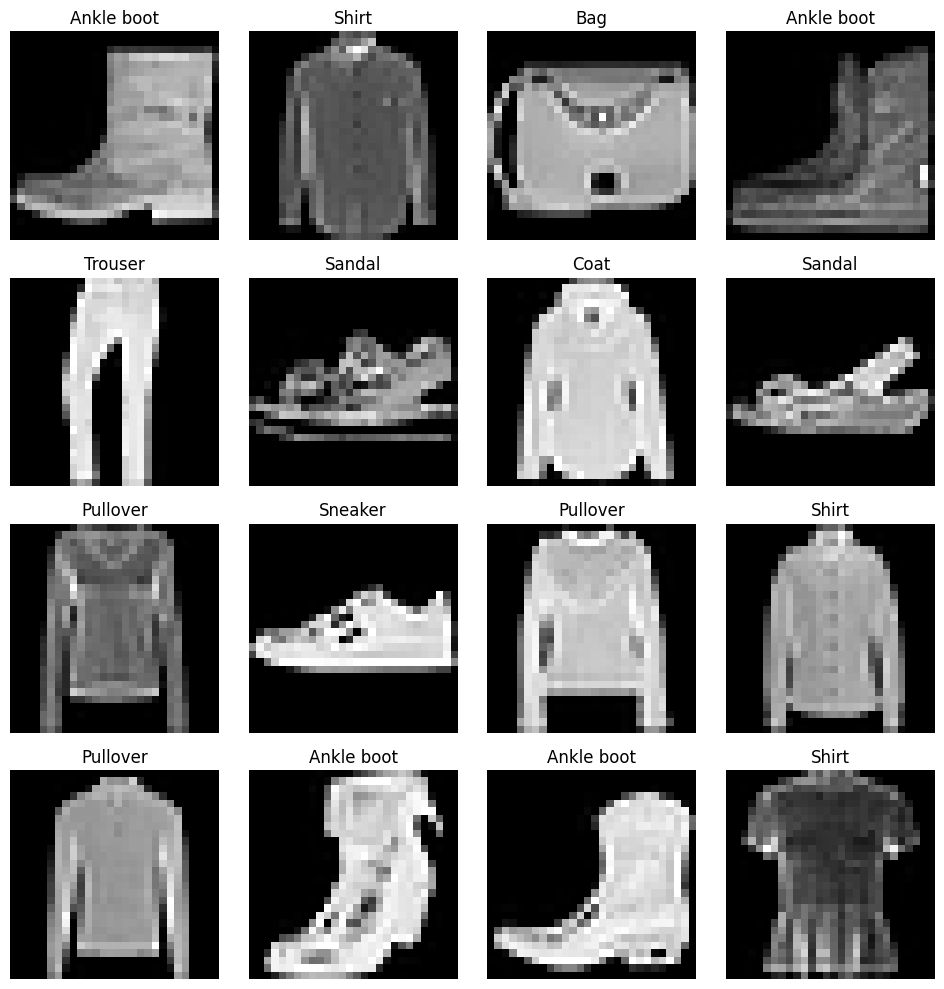

In [8]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(10, 10))
rows, columns = 4, 4

for i in range(1, rows * columns + 1):
  random_idx = torch.randint(0, len(train_data), size = [1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, columns, i)
  plt.title(class_names[label])
  plt.imshow(img.permute(1, 2, 0), cmap = "gray")
  plt.axis(False)
  plt.tight_layout()

# Data Loader

In [9]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_DataLoader = DataLoader(train_data,
                              batch_size = BATCH_SIZE,
                              shuffle= True)

test_DataLoader = DataLoader(test_data,
                             batch_size= BATCH_SIZE,
                             shuffle = False)

In [10]:
train_DataLoader, test_DataLoader

(<torch.utils.data.dataloader.DataLoader at 0x1d3ef6efe00>,
 <torch.utils.data.dataloader.DataLoader at 0x1d3f2186d50>)

In [11]:
print(f"Data Loaders: {train_DataLoader, test_DataLoader}")
print(f"Size of Test Data Loader: {len(train_DataLoader)} \nSize of Train Data Loader: {len(train_DataLoader)}")
print(f"Train Batch Size: {train_DataLoader.batch_size} \nTest Batch Size: {test_DataLoader.batch_size}")

Data Loaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001D3EF6EFE00>, <torch.utils.data.dataloader.DataLoader object at 0x000001D3F2186D50>)
Size of Test Data Loader: 1875 
Size of Train Data Loader: 1875
Train Batch Size: 32 
Test Batch Size: 32


# Model 0

In [12]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # neural networks like their inputs in vector form
            nn.Linear(in_features=input_shape, out_features=hidden_units), # in_features = number of features in a data sample (784 pixels)
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [13]:
torch.manual_seed(42)

# Need to setup model with input parameters
model_0 = FashionMNISTModelV0(input_shape=784, # one for every pixel (28x28)
    hidden_units=10, # how many units in the hidden layer
    output_shape=len(class_names) # one for every class
)
model_0.to("cpu") # keep model on CPU to begin with

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

# Setup Loss Function and Optims

In [14]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [15]:
import torch
from helper_functions import accuracy_fn

loss_fn = torch.nn.CrossEntropyLoss()

Optimizer = torch.optim.SGD(model_0.parameters(),
                            lr = 0.1)

In [16]:
# Time the experiments
from timeit import default_timer as timer

def print_train_time(start_time: float,
                     end_time: float,
                     device: torch.device = None):
  """Prints the Training Time of The Model

  start_time: Takes the input as when the code started
  end_time: Takes the input when the code ended
  device: On which device the code is currently being run
  """

  total_time = end_time - start_time
  print(f"Time taken to train the model on {device}: {total_time:.3f} seconds")


In [17]:
start = timer()
end = timer()

print_train_time(start_time= start,
                 end_time=end,
                 device= "cpu")

Time taken to train the model on cpu: 0.000 seconds


# Create a Training Loop

In [19]:
# Create Progress Bar
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_on_cpu = timer()

epochs = 3

# Create Loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch} \n--------")

  # Training
  train_loss = 0

  # Add a loop to loop thro batches
  for batch, (X , y) in enumerate(train_DataLoader):
     model_0.train()

     # Forward Pass
     y_pred = model_0(X)

     # Loss
     loss = loss_fn(y_pred, y)
     train_loss += loss

     # optimizer zero grad
     Optimizer.zero_grad()

     # Loss Backprop
     loss.backward()

     # optim step
     Optimizer.step()

     if batch % 400 == 0:
      print(f"Batch: {batch * len(X)}/{len(train_DataLoader.dataset)} samples")

  # Divide total train loss
  train_loss /= len(train_DataLoader)

  # Testing
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X, y in test_DataLoader:
      # Forward Pass
      y_test_pred = model_0(X)

      # loss
      loss_test = loss_fn(y_test_pred, y)
      test_loss += loss_test

      # Accuracy
      test_acc += accuracy_fn(y_true=y, y_pred=y_test_pred.argmax(dim = 1))

    # Calculate test loss/ accuracy avg per batch
    test_loss /= len(test_DataLoader)
    test_acc /= len(test_DataLoader)

    # Print out whats happening
    print(f"\n Train Loss: {train_loss:.3f} | Test Loss: {test_loss:.3f} | Test Accuracy: {test_acc:.3f}")

# Calculate Training Time
train_time_end_on_cpu = timer()
total_train_time_on_cpu = train_time_end_on_cpu - train_time_on_cpu


print_train_time(start_time= train_time_on_cpu,
                                           end_time= train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

c:\Users\ACER\Documents\AI\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 
--------
Batch: 0/60000 samples
Batch: 12800/60000 samples
Batch: 25600/60000 samples
Batch: 38400/60000 samples
Batch: 51200/60000 samples


 33%|███▎      | 1/3 [00:06<00:13,  6.78s/it]


 Train Loss: 0.590 | Test Loss: 0.510 | Test Accuracy: 82.039
Epoch: 1 
--------
Batch: 0/60000 samples
Batch: 12800/60000 samples
Batch: 25600/60000 samples
Batch: 38400/60000 samples
Batch: 51200/60000 samples


 67%|██████▋   | 2/3 [00:16<00:08,  8.30s/it]


 Train Loss: 0.476 | Test Loss: 0.480 | Test Accuracy: 83.197
Epoch: 2 
--------
Batch: 0/60000 samples
Batch: 12800/60000 samples
Batch: 25600/60000 samples
Batch: 38400/60000 samples
Batch: 51200/60000 samples


100%|██████████| 3/3 [00:25<00:00,  8.64s/it]


 Train Loss: 0.455 | Test Loss: 0.477 | Test Accuracy: 83.427
Time taken to train the model on cpu: 25.929 seconds


In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Current device on use: {device}")

Current device on use: cuda


# Make Predictions

In [21]:
torch.manual_seed(42)

def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn: torch.nn.Module,
               device: torch.device= device):
  """
  Returns a dictionary containing the results of the model on the data_loader

  model: The given model sent for evaluation
  data_loader: The loader which sends the data in batches
  loss_fn: Loss Function
  accuracy_fn: Accuracy Function
  device: Current device on use

  """

  loss, acc = 0, 0
  model.eval()

  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      X, y = X.to(device), y.to(device)
      # Make Predictions -> Forward Pass
      y_preds = model(X)

      # Loss
      loss += loss_fn(y_preds, y)

      # Accuracy
      acc += accuracy_fn(y_true= y,
                             y_pred = y_preds.argmax(dim = 1))

    # Scale Loss and Accuracy
    loss /= len(data_loader)
    acc /= len(data_loader)

    return {
        "Model_Name: ": model.__class__.__name__,
        "Model_Loss: ": loss.item(),
        "Model_Accuracy: ": acc
        }

In [22]:
model_0_results = eval_model(model= model_0,
                             data_loader= test_DataLoader,
                             loss_fn= loss_fn,
                             accuracy_fn=accuracy_fn,
                             device = "cpu")

model_0_results

100%|██████████| 313/313 [00:00<00:00, 321.17it/s]


{'Model_Name: ': 'FashionMNISTModelV0',
 'Model_Loss: ': 0.47663894295692444,
 'Model_Accuracy: ': 83.42651757188499}

# Device Agnostic Code

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Current device on use: {device}")

Current device on use: cuda


# Run a Model on GPU

In [24]:
# Create a model with non-linear and linear layers
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # flatten inputs into single vector
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

In [25]:
model_1 = FashionMNISTModelV1(input_shape=28*28,
                              hidden_units= 10,
                              output_shape= len(class_names)).to(device)

next(model_1.parameters()).device

device(type='cuda', index=0)

# Setup Loss and Optimizers

In [26]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()

Optimizer = torch.optim.SGD(model_1.parameters(),
                            lr = 0.1)

# Train and Test Loop

In [27]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")


In [28]:
def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )

        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")


In [29]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader= train_DataLoader,
        model=model_1,
        loss_fn=loss_fn,
        optimizer=Optimizer,
        accuracy_fn=accuracy_fn,
        device = device
    )
    test_step(data_loader=test_DataLoader,
        model=model_1,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device = device
    )

train_time_end_on_gpu = timer()
total_train_time_model_1 =  train_time_end_on_gpu - train_time_start_on_gpu
print_train_time(start_time=train_time_start_on_gpu,
                                            end_time=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 1.11456 | Train accuracy: 58.46%


 33%|███▎      | 1/3 [00:06<00:13,  6.61s/it]

Test loss: 0.96320 | Test accuracy: 63.41%

Epoch: 1
---------
Train loss: 0.90905 | Train accuracy: 64.87%


 67%|██████▋   | 2/3 [00:13<00:06,  6.55s/it]

Test loss: 0.74544 | Test accuracy: 72.61%

Epoch: 2
---------
Train loss: 0.59506 | Train accuracy: 78.26%


100%|██████████| 3/3 [00:19<00:00,  6.43s/it]

Test loss: 0.49534 | Test accuracy: 82.68%

Time taken to train the model on cuda: 19.306 seconds


In [30]:
model_1_results = eval_model(model = model_1,
                             data_loader=test_DataLoader,
                             accuracy_fn=accuracy_fn,
                             loss_fn=loss_fn)

model_1_results

100%|██████████| 313/313 [00:00<00:00, 456.58it/s]


{'Model_Name: ': 'FashionMNISTModelV1',
 'Model_Loss: ': 0.49533671140670776,
 'Model_Accuracy: ': 82.67771565495208}

In [31]:
model_0_results

{'Model_Name: ': 'FashionMNISTModelV0',
 'Model_Loss: ': 0.47663894295692444,
 'Model_Accuracy: ': 83.42651757188499}

# Build CNN

In [32]:
class FashionMNISTModelV2(nn.Module):
  """
  Model Architecutre that replicates tiny VGG

  """

  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()

    # Feature Extractors
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size = 3,
                  padding=1,
                  stride = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size = 3,
                  padding=1,
                  stride = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2)
    )

    # Classifier Layer
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units * 7 * 7,
                  out_features = output_shape)
    )

  def forward(self, x : torch.Tensor):
    x = self.conv_block_1(x)
    #print(f"Shape of conv_block_1: {x.shape}")
    x = self.conv_block_2(x)
    #print(f"Shape of conv_block_2: {x.shape}")
    x = self.classifier(x)
    #print(f"Shape of classifier: {x.shape}")
    return x

In [33]:
torch.manual_seed(42)

model_2 = FashionMNISTModelV2(input_shape= 1,
                              hidden_units = 10,
                              output_shape= len(class_names)).to(device)

next(model_2.parameters())

Parameter containing:
tensor([[[[ 0.2548,  0.2767, -0.0781],
          [ 0.3062, -0.0730,  0.0673],
          [-0.1623,  0.1958,  0.2938]]],


        [[[-0.2445,  0.2897,  0.0624],
          [ 0.2463,  0.0451,  0.1607],
          [-0.0471,  0.2570,  0.0493]]],


        [[[-0.1556,  0.0850, -0.1536],
          [-0.0391, -0.1354,  0.2211],
          [-0.2631, -0.1537, -0.0941]]],


        [[[-0.2004,  0.0315, -0.3292],
          [ 0.3010, -0.2832,  0.2573],
          [ 0.0555, -0.1082,  0.2060]]],


        [[[ 0.0520,  0.2693,  0.0364],
          [-0.1051,  0.0896, -0.0904],
          [ 0.1403,  0.2976,  0.1927]]],


        [[[-0.1457,  0.1924,  0.0596],
          [ 0.1693, -0.2032, -0.3300],
          [-0.1288, -0.2557,  0.2735]]],


        [[[ 0.0960,  0.1381,  0.1054],
          [-0.0058,  0.2609, -0.2368],
          [ 0.0210, -0.2275,  0.1028]]],


        [[[-0.1148,  0.1021, -0.0694],
          [ 0.2765, -0.1976, -0.1988],
          [-0.1988,  0.2998,  0.1111]]],


        [[

In [34]:
torch.manual_seed(23)

test_image = torch.randn((32, 1, 64, 64))


In [35]:
test = model_2(image.unsqueeze(0).to(device))

In [36]:
torch.manual_seed(42)
conv_layer = nn.Conv2d(
     in_channels=3,
     out_channels=10,
     kernel_size=3,
     stride= 1,
     padding=1
 )

pooling_layer = nn.MaxPool2d(
    kernel_size= 2
)



In [37]:
conv_layer_2 = nn.Conv2d(
     in_channels=10,
     out_channels=10,
     kernel_size=3,
     stride= 1,
     padding=1
 )



# Setup Loss/Eval Metrics/ Optims

In [38]:
loss_fn = nn.CrossEntropyLoss()

from helper_functions import accuracy_fn

optimizer = torch.optim.SGD(model_2.parameters(),
                            lr = 0.01,
                            momentum=0.9)

In [39]:
model_2.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.2548,  0.2767, -0.0781],
                        [ 0.3062, -0.0730,  0.0673],
                        [-0.1623,  0.1958,  0.2938]]],
              
              
                      [[[-0.2445,  0.2897,  0.0624],
                        [ 0.2463,  0.0451,  0.1607],
                        [-0.0471,  0.2570,  0.0493]]],
              
              
                      [[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
      

In [40]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer
model_2_train_start_time = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch} --------\n")
  train_step(model=model_2,
            data_loader=train_DataLoader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            accuracy_fn=accuracy_fn,
            device = device)
  test_step(model=model_2,
            data_loader=test_DataLoader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

model_2_train_end_time = timer()
total_train_time_model2 = model_2_train_end_time - model_2_train_start_time
print_train_time(start_time=model_2_train_start_time,
                                           end_time=model_2_train_end_time)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 --------

Train loss: 0.61099 | Train accuracy: 77.92%


 33%|███▎      | 1/3 [00:07<00:14,  7.08s/it]

Test loss: 0.41931 | Test accuracy: 85.21%

Epoch: 1 --------

Train loss: 0.36489 | Train accuracy: 86.89%


 67%|██████▋   | 2/3 [00:16<00:08,  8.27s/it]

Test loss: 0.35984 | Test accuracy: 87.00%

Epoch: 2 --------

Train loss: 0.31997 | Train accuracy: 88.45%


100%|██████████| 3/3 [00:25<00:00,  8.36s/it]

Test loss: 0.33108 | Test accuracy: 87.92%

Time taken to train the model on None: 25.087 seconds


In [41]:
model2_results = eval_model(model_2,
                            data_loader=test_DataLoader,
                            loss_fn = loss_fn,
                            accuracy_fn=accuracy_fn,
                            device=device)
model2_results

100%|██████████| 313/313 [00:00<00:00, 432.33it/s]


{'Model_Name: ': 'FashionMNISTModelV2',
 'Model_Loss: ': 0.3310844600200653,
 'Model_Accuracy: ': 87.91932907348243}

In [42]:
model_0_results

{'Model_Name: ': 'FashionMNISTModelV0',
 'Model_Loss: ': 0.47663894295692444,
 'Model_Accuracy: ': 83.42651757188499}

# Compare Model Results

In [44]:
import pandas as pd

compare_results = pd.DataFrame([model_0_results,
                            model_1_results,
                            model2_results])

compare_results

,Model_Name:,Model_Loss:,Model_Accuracy:
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.495337,82.677716
2,FashionMNISTModelV2,0.331084,87.919329


In [45]:
# Add training time
compare_results["training_time"] = [total_train_time_on_cpu,
                                    total_train_time_model_1,
                                    total_train_time_model2]

compare_results

,Model_Name:,Model_Loss:,Model_Accuracy:,training_time
0,FashionMNISTModelV0,0.476639,83.426518,25.928663
1,FashionMNISTModelV1,0.495337,82.677716,19.306428
2,FashionMNISTModelV2,0.331084,87.919329,25.086565


In [46]:
total_train_time_on_cpu, total_train_time_model_1, total_train_time_model2

(25.92866270000013, 19.306428100000176, 25.086565000000064)

Text(0, 0.5, 'Model')

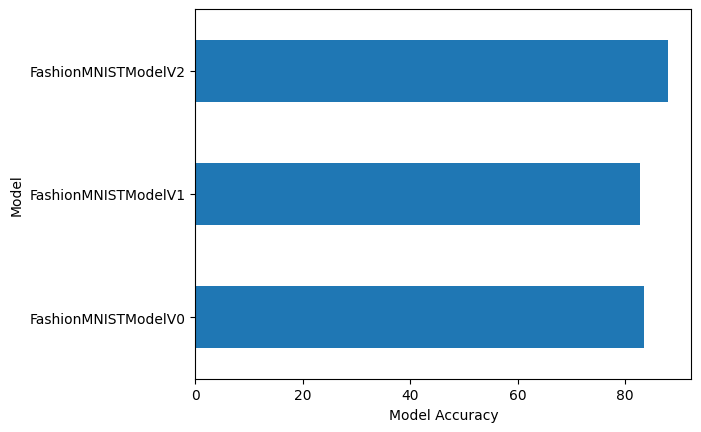

In [47]:
compare_results.set_index("Model_Name: ")["Model_Accuracy: "].plot(kind = "barh")
plt.xlabel("Model Accuracy")
plt.ylabel("Model")

In [48]:
print(compare_results.columns)

Index(['Model_Name: ', 'Model_Loss: ', 'Model_Accuracy: ', 'training_time'], dtype='str')


# Evaluate and plot best model

In [49]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):
  pred_probs = []
  model.to(device)
  model.eval()

  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim = 0).to(device)

      # Forward Pass (Raw logits)
      pred_logit = model(sample)
      # Logits -> probability
      pred_prob = torch.softmax(pred_logit.squeeze(), dim = 0)

      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs, dim = 0)

Test Label: Dress


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

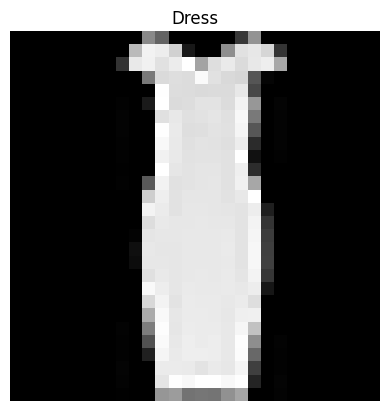

In [50]:
import random
#random.seed(42)

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k = 9):
  test_samples.append(sample)
  test_labels.append(label)

print(f"Test Label: {class_names[test_labels[0]]}")
plt.imshow(test_samples[0].squeeze(), cmap = "gray")
plt.title(class_names[test_labels[0]])
plt.axis(False)

In [51]:
pred_probs = make_predictions(model = model_2,
                              data=test_samples,
                              device = device)
pred_probs[:2]

tensor([[7.1478e-04, 7.6512e-03, 5.1004e-04, 9.8828e-01, 1.4189e-04, 6.7168e-05,
         7.9766e-04, 5.7188e-04, 2.1392e-05, 1.2483e-03],
        [1.5204e-02, 7.5215e-03, 2.1741e-03, 7.6586e-03, 5.9072e-01, 5.2881e-06,
         3.6436e-01, 2.1417e-05, 1.2269e-02, 6.6772e-05]])

In [52]:
pred_classes = pred_probs.argmax(dim = 1)

pred_classes

tensor([3, 4, 3, 9, 9, 3, 9, 4, 9])

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

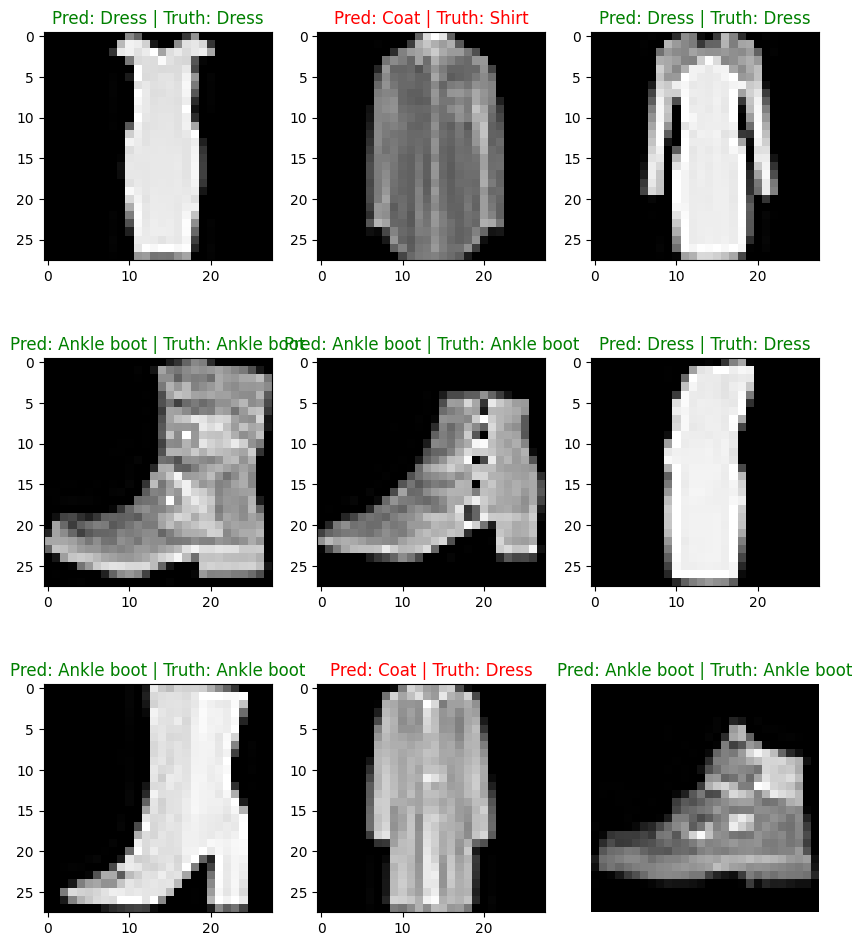

In [53]:
plt.figure(figsize=(10, 12))
nrows = 3
ncols = 3

for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i + 1)

  # plot the target image
  plt.imshow(sample.squeeze(), cmap = "gray")

  # Find the prediction label
  pred_label = class_names[pred_classes[i]]

  # Get the truth label
  truth_label = class_names[test_labels[i]]

  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  if pred_label == truth_label:
    plt.title(title_text, color = "green")
  else:
    plt.title(title_text, color = "red")
plt.axis(False)


# Make a confusion matrix

In [54]:
from tqdm.auto import tqdm

y_preds = []
model_2.eval()

for X, y in tqdm(test_DataLoader, desc="Making predictions......"):
  X, y = X.to(device), y.to(device)

  # Forward Pass
  y_logit = model_2(X)

  # Logits -> Probabilties -> labels
  y_pred = torch.softmax(y_logit,
                         dim = 1).argmax(dim = 1)

  y_preds.append(y_pred.cpu())

pred_tensor = torch.cat(y_preds)

Making predictions......: 100%|██████████| 313/313 [00:01<00:00, 254.15it/s]


In [55]:
pred_tensor

tensor([9, 2, 1,  ..., 8, 1, 5])

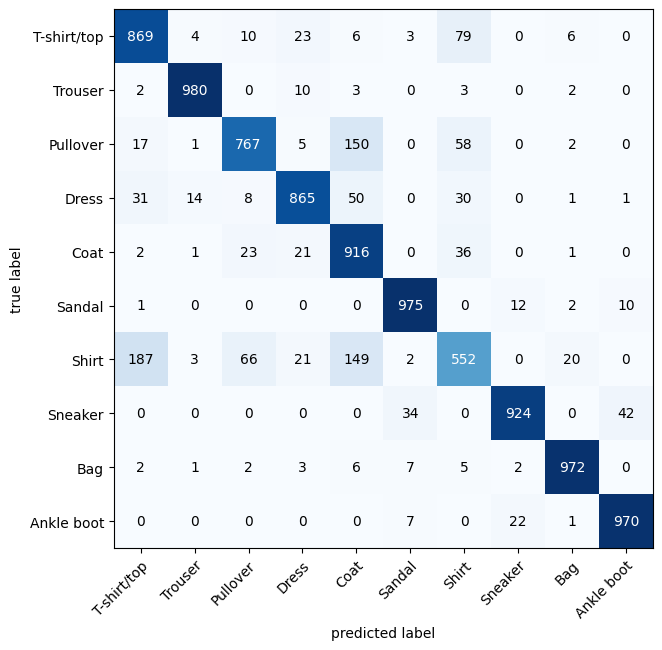

In [60]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(task='multiclass', num_classes=len(class_names))
confmat_tensor = confmat(preds=pred_tensor,
                         target=test_data.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    confmat_tensor.numpy(), # matplotlib likes working with NumPy
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10, 7)
)


# Save/Load Model

In [62]:
from pathlib import Path

# Create models directory 
MODEL_PATH = Path("Models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# Create a model save path
MODEL_NAME = "model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
# Save the model state dict
torch.save(obj=model_2.state_dict(),
           f=MODEL_SAVE_PATH)


Saving model to: Models\model_2.pth


In [64]:
# Load Model
model_2.load_state_dict(torch.load(MODEL_SAVE_PATH))
model_2.to(device)

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [66]:
eval_model(model=model_2,
           data_loader=test_DataLoader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)


100%|██████████| 313/313 [00:01<00:00, 266.46it/s]


{'Model_Name: ': 'FashionMNISTModelV2',
 'Model_Loss: ': 0.3310844600200653,
 'Model_Accuracy: ': 87.91932907348243}